In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import labmate
from labmate.acquisition_notebook import AcquisitionAnalysisManager

from datetime import datetime
from pathlib import Path

In [3]:
import pyvisa as pv

In [4]:
from utils.naming import make_run_dir
from utils.pm100a import record_pm100a

In [5]:
import os
from sys import path
import struct
import time

#### Add DLL to local path

In [6]:
path.append(r"D:/NKT Photonics/Examples/DLL_Example_Python")

In [7]:
from NKTP_DLL import *
from utils.nkt import find_nkt_devices, read_powers_and_temp

Loading x64 DLL from: D:\NKT Photonics\\NKTPDLL\x64\NKTPDLL.dll


In [8]:
DATA_DIR = "data/nkt"
os.makedirs(DATA_DIR, exist_ok=True)

# Power fluctuations

We record the power fluctuations at the laser output (from NKT data) with the power at a given point of the experiment table

#### Check device connections

In [9]:
# Check available VISA resources
rm = pv.ResourceManager()
print(rm.list_resources())

('USB0::0x0699::0x039F::C010359::INSTR', 'USB0::0x1313::0x8079::P1007388::INSTR', 'ASRL1::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR')


In [10]:
# Connect to power meter via PyVISA
# you can use the tool Power Meter Driver Switcher to switch between the two drivers, the PM100D.dll driver and the new TLPM.dll driver. 
# Pyvisa may not recognize the PM100A with the WinUSB driver, so you may need to switch to the Visa driver. 
# PM100A
pm = rm.open_resource('USB0::0x1313::0x8079::P1007388::INSTR')  # PANDA powermeter
print(pm.query('*IDN?'))

# PM100D 
# pm = rm.open_resource('USB0::0x1313::0x8078::P0008159::INSTR')  # PESTO powermeter
# pm = rm.open_resource('USB0::0x1313::0x8078::P0025589::INSTR')  # Musiqs powermeter
# print(pm.query('*IDN?'))

Thorlabs,PM100A,P1007388,2.5.0



In [11]:
open_ports = find_nkt_devices()

Scanning: COM1,COM4,COM5
Open result: 1:OPFailed
No NKT devices found


In [20]:
result, data = registerRead('COM4', 128, 0x1F, -1)

print(RegisterResultTypes(result))
print(repr(data))
print(len(data))

0:RegResultSuccess
b'\xf1\x03'
2


In [23]:
MEAS = "laser_fluctuation"
SAMPLE = "shg_injection"

RUN_DIR = make_run_dir(data_dir=DATA_DIR, meas=MEAS, sample=SAMPLE)
ACQ_CELL = f"{MEAS}_{SAMPLE}"

Directory 2026-06-18_shg_injection_001 already exists. Incrementing index.
Directory 2026-06-18_shg_injection_002 already exists. Incrementing index.
Directory 2026-06-18_shg_injection_003 already exists. Incrementing index.
Directory 2026-06-18_shg_injection_004 already exists. Incrementing index.
Directory 2026-06-18_shg_injection_005 already exists. Incrementing index.
Directory 2026-06-18_shg_injection_006 already exists. Incrementing index.
Directory 2026-06-18_shg_injection_007 already exists. Incrementing index.
Saving data to: data/nkt\laser_fluctuation\2026-06-18_shg_injection_008


In [24]:
minutes = 10
ACQ_DURATION = minutes * 60 
PM_SAMPLE_DELAY = 0.1 # 100 ms

In [25]:
timestamps = []
pm_power_mW = []

harmonik_input = []
harmonik_output = []
harmonik_temp = []

t0 = time.perf_counter()

aqm = AcquisitionAnalysisManager(RUN_DIR)
aqm.acquisition_cell(ACQ_CELL)

while True:

    t = time.perf_counter() - t0

    if t >= ACQ_DURATION:
        break

    pm_value = float(pm.query("MEAS:POW?").strip())

    h_in, h_out, h_temp = read_powers_and_temp()

    timestamps.append(t)
    pm_power_mW.append(pm_value * 1e3)

    harmonik_input.append(h_in)
    harmonik_output.append(h_out)
    harmonik_temp.append(h_temp)

    time.sleep(PM_SAMPLE_DELAY)

timestamps      = np.array(timestamps)
pm_power_mW     = np.array(pm_power_mW)

harmonik_input  = np.array(harmonik_input)
harmonik_output   = np.array(harmonik_output)
harmonik_temp   = np.array(harmonik_temp)

aqm.save_acquisition(
    timestamps=timestamps,
    pm_power_mW=pm_power_mW,
    harmoniharmonik_input=harmonik_input,
    harmonik_output=harmonik_output,
    harmonik_temp=harmonik_temp,
)

INFO:1:2026_06_18__11_37_43__laser_fluctuation_shg_injection


In [31]:
harmonik_input_mW = np.array(harmonik_input) * 1e3
harmonik_output_mW = np.array(harmonik_output) * 1e3

harmonik_input_rel = (
    100 * (harmonik_input_mW - np.mean(harmonik_input_mW))
    / np.mean(harmonik_input_mW)
)

harmonik_output_rel = (
    100 * (harmonik_output_mW - np.mean(harmonik_output_mW))
    / np.mean(harmonik_output_mW)
)

pm_rel = (
    100 * (pm_power_mW - np.mean(pm_power_mW))
    / np.mean(pm_power_mW)
)

harmonik_temp_rel = (
    100 * (harmonik_temp - np.mean(harmonik_temp))
    / np.mean(harmonik_temp)
)

In [32]:
pm_rms = np.array([
    np.std(pm_rel[:i+1])
    for i in range(len(pm_rel))
])

harmonik_input_rms = np.array([
    np.std(harmonik_input_rel[:i+1])
    for i in range(len(harmonik_input_rel))
])

harmonik_output_rms = np.array([
    np.std(harmonik_output_rel[:i+1])
    for i in range(len(harmonik_output_rel))
])

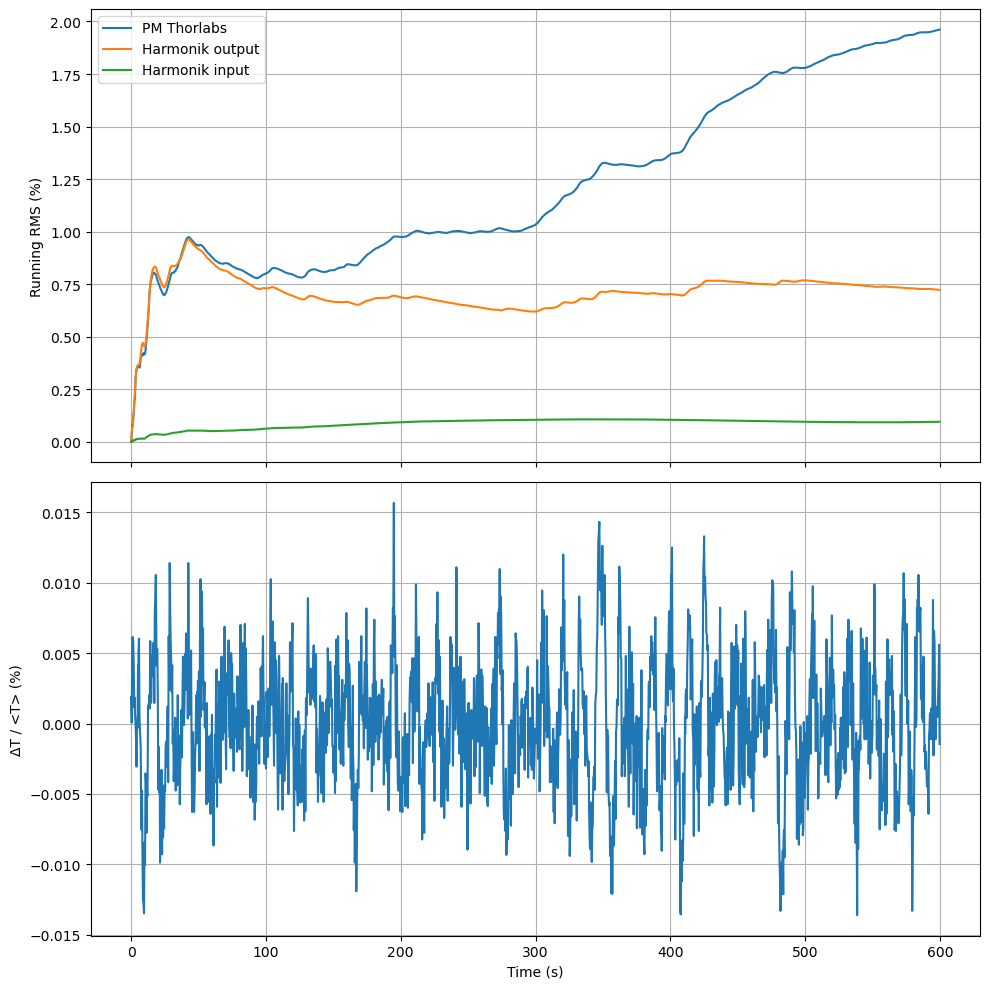

<Figure size 640x480 with 0 Axes>

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# RMS stability
ax[0].plot(timestamps, pm_rms, label="PM Thorlabs")
ax[0].plot(timestamps, harmonik_output_rms, label="Harmonik output")
ax[0].plot(timestamps, harmonik_input_rms, label="Harmonik input")

ax[0].set_ylabel("Running RMS (%)")
ax[0].legend()
ax[0].grid(True)

# # Harmonik temperature
# ax[1].plot(timestamps, harmonik_temp)

# ax[1].ticklabel_format(
#     axis='y',
#     style='plain',
#     useOffset=False
# )

# ax[1].set_ylabel("Temperature (°C)")
# ax[1].set_xlabel("Time (s)")
# ax[1].grid(True)

# Temperature relative fluctuation
ax[1].plot(timestamps, harmonik_temp_rel)

ax[1].set_ylabel("ΔT / <T> (%)")
ax[1].set_xlabel("Time (s)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

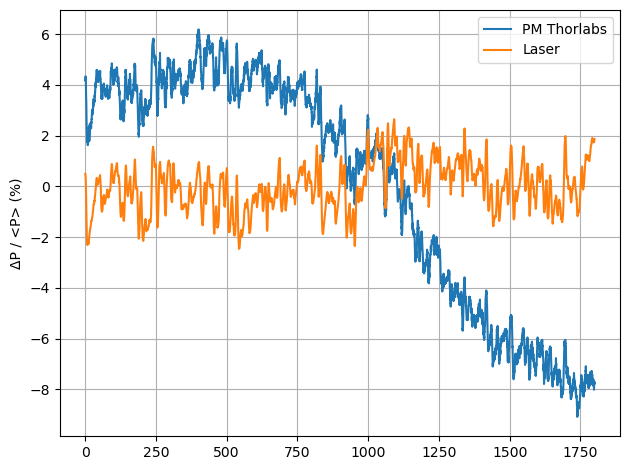

In [ ]:
pm_rel = 100 * (pm_power_mW - np.mean(pm_power_mW)) / np.mean(pm_power_mW)
laser_power = laser_power * 1e3 # convert to mW
laser_rel = 100 * (laser_power - np.mean(laser_power)) / np.mean(laser_power)

# Running peak-to-peak (%)
pm_running_ptp = 100 * (np.maximum.accumulate(pm_power_mW) - np.minimum.accumulate(pm_power_mW))/np.mean(pm_power_mW)
laser_running_ptp = 100 * (np.maximum.accumulate(laser_power) - np.minimum.accumulate(laser_power))/np.mean(laser_power)

plt.figure()

# plt.subplot(3, 1, 1)
# plt.plot(timestamps, pm_power_mW, label="PM Thorlabs")
# plt.plot(timestamps, laser_power, label="Laser")
# plt.ylabel("Power (mW)")
# plt.legend()
# plt.grid()

# plt.subplot(2, 1, 1)
# plt.plot(timestamps, laser_temp)
# # plt.plot(timestamps, laser_power, label="Laser")
# plt.ylabel("Temperature")
# plt.legend()
# plt.grid()

# plt.subplot(2, 1, 2)
plt.plot(timestamps, pm_rel, label="PM Thorlabs")
plt.plot(timestamps, laser_rel, label="Laser")
plt.ylabel("ΔP / <P> (%)")
plt.legend()
plt.grid()


plt.tight_layout()
plt.show()